# 🚁 SSD MobileNet V3 - Drone Detection (Kaggle Edition)

**Model:** SSD Lite MobileNet V3 (Torchvision)  
**Speed:** Ultra-Fast (Real-time on CPU/Edge)  
**Dataset:** cybersimar08/drone-detection

---

### 1. Setup & Imports

In [6]:
import os
import glob
import time
import torch
import torchvision
import cv2
import numpy as np
import yaml
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import ssdlite320_mobilenet_v3_large

# Check Device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"✅ Hardware: {device} (Ready)")

✅ Hardware: cuda (Ready)


### 2. Locate Dataset & Define Class

In [21]:
# Cell 2: Find Dataset Path
import glob
import os

# Kaggle attaches datasets to /kaggle/input/
print("🔍 Searching for dataset...")
yaml_files = glob.glob('/kaggle/input/**/data.yaml', recursive=True)

if not yaml_files:
    print("❌ ERROR: Dataset not found! Make sure you added it in the sidebar.")
    raise FileNotFoundError("Please add 'cybersimar08/drone-detection' in the sidebar.")
else:
    yaml_path = yaml_files[0]
    dataset_root = os.path.dirname(yaml_path)
    print(f"✅ Dataset found at: {dataset_root}")

🔍 Searching for dataset...
✅ Dataset found at: /kaggle/input/datasets/cybersimar08/drone-detection/drone-detection-new.v5-new-train.yolov8


### 3. Build Model (SSD MobileNet)

In [22]:
# Cell 3: Fix YAML for Kaggle
import yaml

# Read existing config
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

# Update to Kaggle absolute paths
data_config['path'] = dataset_root
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images'
data_config['test'] = 'test/images'

# Save the new config to a writable folder
new_yaml_path = '/kaggle/working/data_kaggle.yaml'
with open(new_yaml_path, 'w') as f:
    yaml.dump(data_config, f)

print(f"✅ New config saved to: {new_yaml_path}")

✅ New config saved to: /kaggle/working/data_kaggle.yaml


### 4. Train Loop

🧠 Initializing SSD MobileNet V3 Large...
✅ Model head matched to backbone channels: [672, 480, 512, 256, 256, 128]
✅ Found 10799 images in train set
🔥 Starting Training (30 Epochs) on cuda...
  [Epoch 1, Batch 50/338] Loss: 3.8054
  [Epoch 1, Batch 100/338] Loss: 3.8663
  [Epoch 1, Batch 150/338] Loss: 2.5542
  [Epoch 1, Batch 200/338] Loss: 2.7193
  [Epoch 1, Batch 250/338] Loss: 2.5338
  [Epoch 1, Batch 300/338] Loss: 2.8543
🏁 Epoch 1/30 Finished | Avg Loss: 3.4438
  [Epoch 2, Batch 50/338] Loss: 2.4445
  [Epoch 2, Batch 100/338] Loss: 2.4349
  [Epoch 2, Batch 150/338] Loss: 2.1627
  [Epoch 2, Batch 200/338] Loss: 2.5641
  [Epoch 2, Batch 250/338] Loss: 2.6541
  [Epoch 2, Batch 300/338] Loss: 1.9900
🏁 Epoch 2/30 Finished | Avg Loss: 2.1782
  [Epoch 3, Batch 50/338] Loss: 2.0001
  [Epoch 3, Batch 100/338] Loss: 2.2177
  [Epoch 3, Batch 150/338] Loss: 1.6570
  [Epoch 3, Batch 200/338] Loss: 2.0098
  [Epoch 3, Batch 250/338] Loss: 1.8234
  [Epoch 3, Batch 300/338] Loss: 1.6561
🏁 Epoch 3

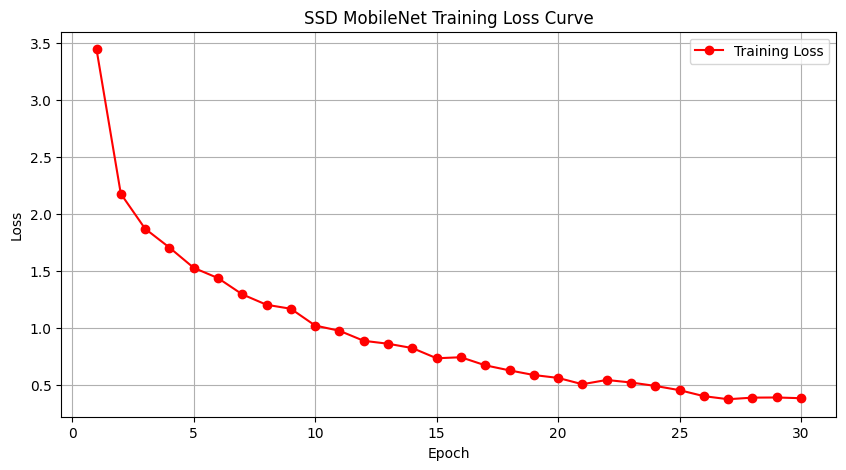

💾 Weights saved as ssd_drone_model.pth in 58.90 mins


In [28]:
# MASTER TRAINING CELL (SSD MobileNet V3 Large - Final Corrected with Logging)
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection.ssd import SSDClassificationHead
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
import cv2
import numpy as np
import time
import os
import matplotlib.pyplot as plt

# --- 1. DATA LOADER ---
class DroneDataset(Dataset):
    def __init__(self, root, split='train'):
        self.imgs_dir = os.path.join(root, split, 'images')
        self.labels_dir = os.path.join(root, split, 'labels')
        
        if not os.path.exists(self.imgs_dir):
            raise FileNotFoundError(f"Missing folder: {self.imgs_dir}")
            
        self.imgs = sorted([f for f in os.listdir(self.imgs_dir) if f.lower().endswith(('.jpg', '.png'))])
        print(f"✅ Found {len(self.imgs)} images in {split} set")

    def __getitem__(self, idx):
        img_path = os.path.join(self.imgs_dir, self.imgs[idx])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        h, w, _ = img.shape
        img_tensor = torch.from_numpy(img).permute(2, 0, 1)

        label_path = os.path.join(self.labels_dir, os.path.splitext(self.imgs[idx])[0] + '.txt')
        boxes, labels = [], []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    d = list(map(float, line.strip().split()))
                    c, x, y, bw, bh = int(d[0]), d[1], d[2], d[3], d[4]
                    xmin, ymin = (x - bw/2) * w, (y - bh/2) * h
                    xmax, ymax = (x + bw/2) * w, (y + bh/2) * h
                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(c + 1)

        target = {'boxes': torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
                  'labels': torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)}
        return img_tensor, target

    def __len__(self): return len(self.imgs)

def collate_fn(batch): return tuple(zip(*batch))

# --- 2. INITIALIZE MODEL ---
print("🧠 Initializing SSD MobileNet V3 Large...")
model = ssdlite320_mobilenet_v3_large(weights='DEFAULT')

# Final channel counts for MobileNet V3 Large
in_channels = [672, 480, 512, 256, 256, 128] 
num_anchors = model.anchor_generator.num_anchors_per_location()
num_classes = len(class_names) + 1 

model.head.classification_head = SSDClassificationHead(in_channels, num_anchors, num_classes)
model.to(device)
print(f"✅ Model head matched to backbone channels: {in_channels}")

# --- 3. TRAINING LOOP ---
train_ds = DroneDataset(dataset_root, split='train')
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2, collate_fn=collate_fn)
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

print(f"🔥 Starting Training (30 Epochs) on {device}...")
epoch_losses = []
start_time = time.time()

for epoch in range(30):
    model.train()
    running_loss = 0
    
    for i, (images, targets) in enumerate(train_loader):
        images = list(img.to(device) for img in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        
        running_loss += losses.item()
        
        # Real-time batch logging every 50 batches
        if (i + 1) % 50 == 0:
            print(f"  [Epoch {epoch+1}, Batch {i+1}/{len(train_loader)}] Loss: {losses.item():.4f}")
    
    avg_loss = running_loss / len(train_loader)
    epoch_losses.append(avg_loss)
    print(f"🏁 Epoch {epoch+1}/30 Finished | Avg Loss: {avg_loss:.4f}")

# Plotting the loss curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), epoch_losses, marker='o', color='red', label='Training Loss')
plt.title('SSD MobileNet Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Save final weights
torch.save(model.state_dict(), '/kaggle/working/ssd_drone_model.pth')
print(f"💾 Weights saved as ssd_drone_model.pth in {(time.time()-start_time)/60:.2f} mins")

In [31]:
# Initialize the validation dataset
valid_ds = DroneDataset(dataset_root, split='valid')
print(f"✅ Validation dataset initialized with {len(valid_ds)} images.")

✅ Found 603 images in valid set
✅ Validation dataset initialized with 603 images.


### 5. Visualize Results (Output)
This cell will pick a random test image and show the detections.

In [ ]:
# NEW CELL: Test SSD MobileNet on 6 Random Images (Grid View)
import random
import matplotlib.pyplot as plt

model.eval()

# 1. Select 6 random indices from valid_ds
num_images = 6
indices = random.sample(range(len(valid_ds)), num_images)

# 2. Setup the 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

print(f"👁️ Running inference on {num_images} random validation images...")

with torch.no_grad():
    for i, idx in enumerate(indices):
        img_tensor, _ = valid_ds[idx]
        
        # Run inference
        prediction = model([img_tensor.to(device)])[0]
        
        # Prepare image for display
        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = (img_np * 255).astype(np.uint8)
        img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        
        detections = {}
        
        # Draw detections with confidence > 0.4
        for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
            if score > 0.4:
                xmin, ymin, xmax, ymax = box.cpu().numpy().astype(int)
                
                # Get class name safely
                cls_idx = label.item() - 1
                name = class_names[cls_idx] if cls_idx < len(class_names) else f"ID:{label.item()}"
                
                # Count for title
                detections[name] = detections.get(name, 0) + 1
                
                # Draw Box and Label
                cv2.rectangle(img_np, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
                cv2.putText(img_np, f"{name} {score:.2f}", (xmin, ymin-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Plot in grid
        axes[i].imshow(cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB))
        axes[i].axis('off')
        
        # Set title with counts
        title = ', '.join([f'{k}:{v}' for k,v in detections.items()]) if detections else 'No detections'
        axes[i].set_title(f"Img {idx}: {title}", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()
print('✓ Grid visualization complete')